# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.9.2
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [9]:
# Try loading one file

df = pd.read_parquet(r"C:\Users\bhav3\OneDrive\Desktop\Datasets and Dictionary\trip_records\2023-1.parquet")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [16]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [18]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
    # Take a small percentage of entries from each hour of every date.
    # Iterating through the monthly data:
    #   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
    # Create a single dataframe for the year combining all the monthly data
    
    # Select the folder having data files
    import os
    
    # Select the folder having data files
    os.chdir(r"C:\Users\bhav3\OneDrive\Desktop\Datasets and Dictionary\trip_records")
    
    # Create a list of all the twelve files to read
    file_list = os.listdir()
    
    # initialise an empty dataframe
    df = pd.DataFrame()
    
    
    # iterate through the list of files and sample one by one:
    for file_name in file_list:
        try:
            # file path for the current file
            file_path = os.path.join(os.getcwd(), file_name)
    
            # Reading the current file
            data = pd.read_parquet(file_path)
            data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
            # Extract just the date part and the hour part
            data['date'] = data['tpep_pickup_datetime'].dt.date
            data['hour'] = data['tpep_pickup_datetime'].dt.hour
        
            # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
            # After completing iteration through each date, we will append this data to the final dataframe.
            sampled_data = pd.DataFrame()
            unique_dates = data['date'].unique()
        
        
            # Loop through dates and then loop through every hour of each date
            for date in unique_dates:
                day_data = data[data['date'] == date]
        
                # Iterate through each hour of the selected date
                for hour in range(24):
                    hourly_data = day_data[day_data['hour'] == hour]
        
                    # Sample 5% of the hourly data randomly
                    if not hourly_data.empty:
                        sampled_hour = hourly_data.sample(frac=0.05, random_state=1)
                        sampled_data = pd.concat([sampled_data, sampled_hour], ignore_index=True)
        
                        # add data of this hour to the dataframe
        
             # Concatenate the sampled data of all the dates to a single dataframe/
                df = pd.concat([df, sampled_data], ignore_index=True)
        
        except Exception as e:
                print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [25]:
print(f"Total entries in final DataFrame: {len(df)}")
if len(df) > 300000:
    df = df.sample(n=300000, random_state=1).reset_index(drop=True)
# Store the df in csv/parquet
df.to_csv("sampled_nyc_taxi_data.csv", index=False)
# df.to_parquet('')
df.to_parquet("sampled_nyc_taxi_data.parquet", index=False)

Total entries in final DataFrame: 28561884


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [28]:
# Load the new data file
df = pd.read_csv("sampled_nyc_taxi_data.csv")
print(df.shape)

(300000, 22)


In [31]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,date,hour,Airport_fee
0,2,2023-10-02 19:12:22,2023-10-02 19:26:26,1.0,1.87,1.0,N,231,113,4,...,0.5,0.00,0.0,1.0,21.40,2.5,NaN,2023-10-02,19,0.0
1,1,2023-04-20 18:34:20,2023-04-20 19:00:27,0.0,3.30,1.0,N,161,211,1,...,0.5,4.50,0.0,1.0,32.20,2.5,NaN,2023-04-20,18,0.0
2,1,2023-08-05 15:58:40,2023-08-05 16:16:29,1.0,2.90,1.0,N,162,143,1,...,0.5,4.05,0.0,1.0,24.35,2.5,NaN,2023-08-05,15,0.0
3,1,2023-04-09 12:48:15,2023-04-09 12:53:28,1.0,0.80,1.0,N,237,161,1,...,0.5,2.20,0.0,1.0,13.40,2.5,NaN,2023-04-09,12,0.0
4,2,2023-08-07 07:09:31,2023-08-07 07:22:38,1.0,1.40,1.0,N,24,74,1,...,0.5,3.14,0.0,1.0,18.84,0.0,NaN,2023-08-07,7,0.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               300000 non-null  int64  
 1   tpep_pickup_datetime   300000 non-null  object 
 2   tpep_dropoff_datetime  300000 non-null  object 
 3   passenger_count        290575 non-null  float64
 4   trip_distance          300000 non-null  float64
 5   RatecodeID             290575 non-null  float64
 6   store_and_fwd_flag     290575 non-null  object 
 7   PULocationID           300000 non-null  int64  
 8   DOLocationID           300000 non-null  int64  
 9   payment_type           300000 non-null  int64  
 10  fare_amount            300000 non-null  float64
 11  extra                  300000 non-null  float64
 12  mta_tax                300000 non-null  float64
 13  tip_amount             300000 non-null  float64
 14  tolls_amount           300000 non-nu

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [35]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)
df.columns


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'date', 'hour',
       'Airport_fee'],
      dtype='object')

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [37]:
# Combine the two airport fee columns
df['airport_fee'] = df['airport_fee'].combine_first(df['Airport_fee'])
df.drop(columns=['Airport_fee'], inplace=True)


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [39]:
df = pd.read_csv("sampled_nyc_taxi_data.csv")

# check where values of fare amount are negative
df[df['fare_amount'] < 0]



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,date,hour,Airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [41]:
# Analyse RatecodeID for the negative fare amounts
neg_fare_df = df[df['fare_amount'] < 0]


In [43]:
# Find which columns have negative values
numeric_columns = df.select_dtypes(include=['number']).columns
columns_with_negatives = []

for col in numeric_columns:
    if (df[col] < 0).any():
        columns_with_negatives.append(col)

print("Columns that contain negative values:")
print(columns_with_negatives)


Columns that contain negative values:
['mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [45]:
# fix these negative values
cols_to_fix = ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

# Replacing negative values with 0
for col in cols_to_fix:
    df[col] = df[col].apply(lambda x: x if x >= 0 else 0)


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [47]:
# Find the proportion of missing values in each column
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0]
print("Proportion of missing values in each column:")
print(missing_ratio)


Proportion of missing values in each column:
airport_fee           0.913263
passenger_count       0.031417
RatecodeID            0.031417
store_and_fwd_flag    0.031417
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [50]:
# Display the rows with null values
df[df['passenger_count'].isnull()]

# Impute NaN values in 'passenger_count'
most_common = df['passenger_count'].mode()[0]
df['passenger_count'].fillna(most_common, inplace=True)
zero_passengers = df[df['passenger_count'] == 0]
print(f"Trips with passenger_count = 0: {len(zero_passengers)}")
df[df['passenger_count'] == 0].head()


Trips with passenger_count = 0: 4646


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,date,hour,Airport_fee
1,1,2023-04-20 18:34:20,2023-04-20 19:00:27,0.0,3.3,1.0,N,161,211,1,...,0.5,4.50,0.00,1.0,32.20,2.5,NaN,2023-04-20,18,0.00
31,1,2023-12-03 10:24:19,2023-12-03 10:52:58,0.0,4.9,1.0,N,230,261,1,...,0.5,5.00,0.00,1.0,39.30,2.5,NaN,2023-12-03,10,0.00
36,1,2023-10-03 14:34:17,2023-10-03 14:46:12,0.0,0.9,1.0,N,162,237,1,...,0.5,3.05,0.00,1.0,18.45,2.5,NaN,2023-10-03,14,0.00
144,1,2023-03-08 22:27:15,2023-03-08 22:36:01,0.0,1.9,1.0,N,236,43,2,...,0.5,0.00,0.00,1.0,17.10,2.5,NaN,2023-03-08,22,0.00
240,1,2023-11-27 23:43:45,2023-11-27 23:55:44,0.0,8.0,1.0,N,138,170,1,...,0.5,9.90,6.94,1.0,59.59,2.5,NaN,2023-11-27,23,1.75


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

Did you find zeroes in passenger_count? Handle these.

In [54]:
df = df[df['passenger_count'] != 0]
# Fix missing values in 'RatecodeID'
print("Missing values in 'RatecodeID':", df['RatecodeID'].isnull().sum())
print("Value counts for RatecodeID:")
print(df['RatecodeID'].value_counts())
most_common_ratecode = df['RatecodeID'].mode()[0]
df['RatecodeID'].fillna(most_common_ratecode, inplace=True)

Missing values in 'RatecodeID': 9425
Value counts for RatecodeID:
RatecodeID
1.0     270030
2.0      11131
99.0      1677
5.0       1609
3.0        934
4.0        548
Name: count, dtype: int64


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [57]:
# handle null values in congestion_surcharge
print("Missing values in 'congestion_surcharge':", df['congestion_surcharge'].isnull().sum())
most_common_surcharge = df['congestion_surcharge'].mode()[0]
df['congestion_surcharge'].fillna(most_common_surcharge, inplace=True)



Missing values in 'congestion_surcharge': 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [60]:
# Handle any remaining missing values
# Check which columns still have missing values
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]
print("Columns with remaining missing values")
print(missing_cols)
df['store_and_fwd_flag'].fillna('N', inplace=True)
df['airport_fee'].fillna(0, inplace=True)

Columns with remaining missing values
store_and_fwd_flag      9425
airport_fee           269784
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [66]:
# Describe the data and check if there are any potential outliers present
df.describe()


# Check for potential out of place values in various columns



,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,hour,Airport_fee
count,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000,295354.000000
mean,1.747120,1.375126,3.665646,1.627806,165.542078,164.276817,1.162358,19.713645,1.562783,0.495404,3.561779,0.592152,0.998936,28.792777,2.240618,0.010094,14.286639,0.121535
std,0.440928,0.865967,62.548351,7.368250,63.993986,69.861186,0.500295,18.184386,1.815285,0.048704,4.039679,2.182614,0.029854,22.727731,0.762348,0.111872,5.814038,0.429916
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.050000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000,11.000000,0.000000
50%,2.000000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.860000,0.000000,1.000000,21.000000,2.500000,0.000000,15.000000,0.000000
75%,2.000000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,30.670000,2.500000,0.000000,19.000000,0.000000
max,6.000000,8.000000,27909.290000,99.000000,265.000000,265.000000,4.000000,700.000000,11.750000,4.000000,200.000000,87.750000,1.000000,707.940000,2.500000,1.250000,23.000000,1.750000


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [71]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]


In [73]:
# Continue with outlier handling
# 1.Entries where trip_distance is nearly 0 and fare_amount is more than 300
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]
# 2.Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
df = df[~((df['trip_distance'] == 0) & 
          (df['fare_amount'] == 0) & 
          (df['PULocationID'] != df['DOLocationID']))]
#3.Entries where trip_distance is more than 250 miles.
df = df[df['trip_distance'] <= 250]
#4.Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)
df = df[df['payment_type'] != 0]
#5. some have negative values 


In [75]:
# Do any columns need standardising?
#No 


NameError: name 'No' is not defined

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [77]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'date',
 'hour',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

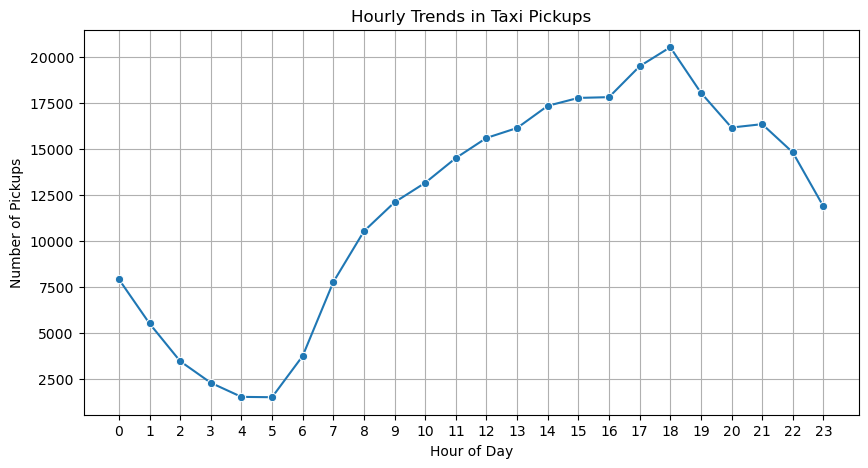

In [79]:
# Find and show the hourly trends in taxi pickups
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_counts = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker='o')
plt.xticks(range(0, 24))
plt.title('Hourly Trends in Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.grid(True)
plt.show()


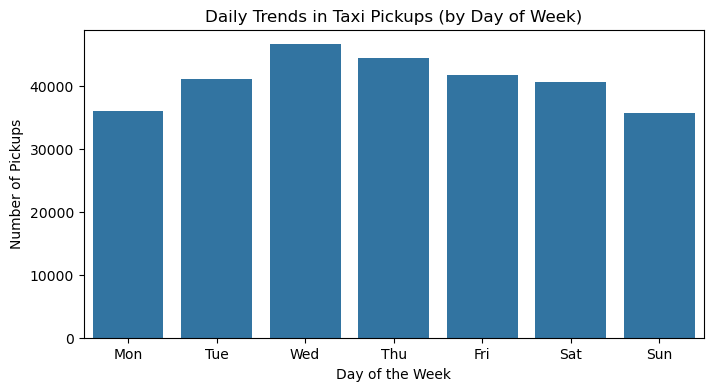

In [81]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['pickup_dayofweek'] = df['pickup_dayofweek'].map(day_map)
plt.figure(figsize=(8, 4))
sns.countplot(x='pickup_dayofweek', data=df, order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Daily Trends in Taxi Pickups (by Day of Week)')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.show()



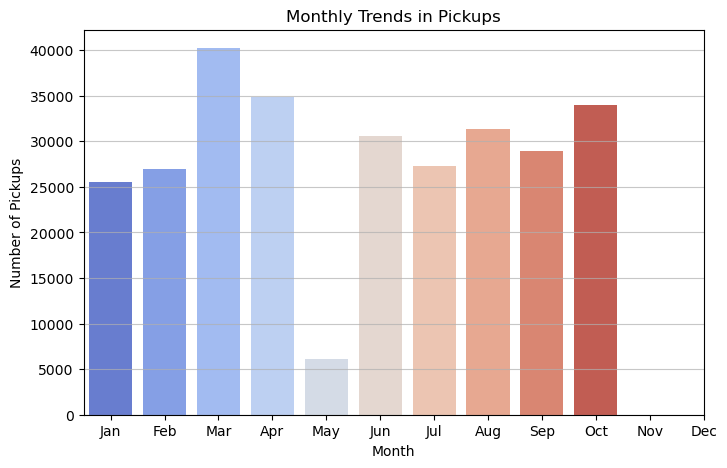

In [83]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
plt.figure(figsize=(8, 5))
sns.countplot(x='pickup_month', data=df, palette='coolwarm')
plt.title('Monthly Trends in Pickups')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', alpha=0.7)
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [85]:
# Analyse the above parameters
cols_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
for col in cols_to_check:
    zeros=(df[col] == 0).sum()
    negatives=(df[col] < 0).sum()
    print(f"{col} --> Zero values: {zeros}, Negative values: {negatives}")





fare_amount --> Zero values: 97, Negative values: 0
tip_amount --> Zero values: 62714, Negative values: 0
total_amount --> Zero values: 49, Negative values: 0
trip_distance --> Zero values: 3266, Negative values: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [89]:
# Create a df with non zero entries for the selected parameters.
valid_distance = (df['trip_distance'] > 0) | (
    (df['trip_distance'] == 0) & (df['PULocationID'] == df['DOLocationID'])
)

# Final filter condition for non-zero financials and valid distance logic
df_nonzero = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    valid_distance
].copy()


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [91]:
# Group data by month and analyse monthly revenue
df_nonzero['pickup_month'] = df_nonzero['tpep_pickup_datetime'].dt.month
monthly_revenue = df_nonzero.groupby('pickup_month')['total_amount'].sum().sort_index() #group by
print("Monthly Revenue (in $):")
print(monthly_revenue)


Monthly Revenue (in $):
pickup_month
1      707112.78
2      729052.90
3     1126827.18
4      992698.92
5      181701.65
6      885417.56
8      787933.48
10     938395.78
11     845732.57
12     992142.85
Name: total_amount, dtype: float64


In [93]:
# Calculate proportion of each quarter
df_nonzero['pickup_quarter'] = df_nonzero['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df_nonzero.groupby('pickup_quarter')['total_amount'].sum() #group by
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100
print("Quarterly Revenue Proportion (%):")
print(quarterly_proportion.round(2))


Quarterly Revenue Proportion (%):
pickup_quarter
1    31.31
2    25.16
3     9.62
4    33.91
Name: total_amount, dtype: float64


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

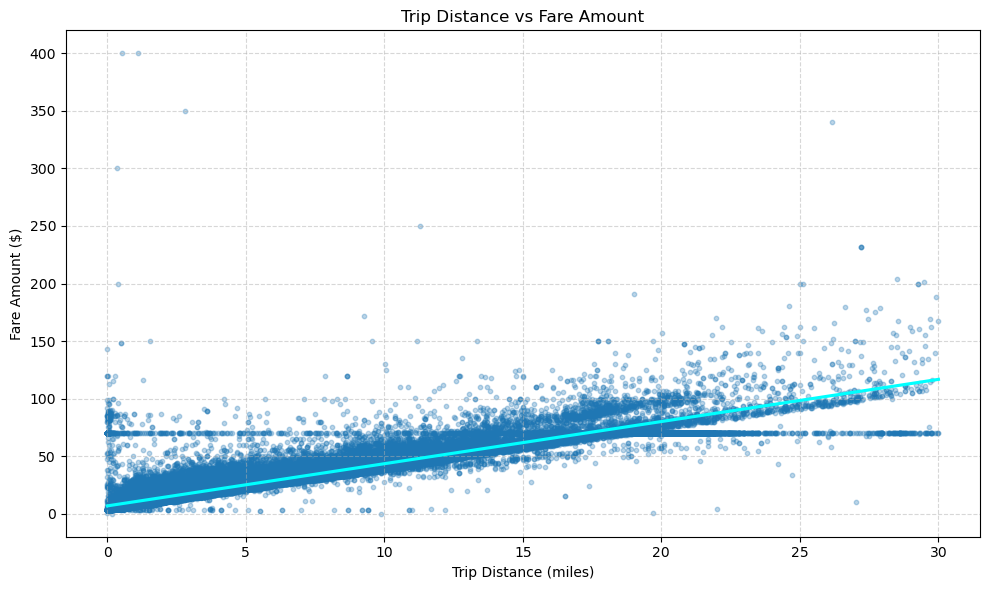

In [95]:
# Show how trip fare is affected by distance

df_valid = df_nonzero[(df_nonzero['trip_distance'] > 0) & (df_nonzero['fare_amount'] > 0)]
df_plot = df_valid[df_valid['trip_distance'] <= 30]

plt.figure(figsize=(10, 6))

# Plotting distance vs fare with a trendline
sns.regplot(
    data=df_plot,
    x='trip_distance',
    y='fare_amount',
    scatter_kws={'alpha': 0.3, 's': 10},  
    line_kws={'color': 'cyan'},            
    ci=None                             
)

plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

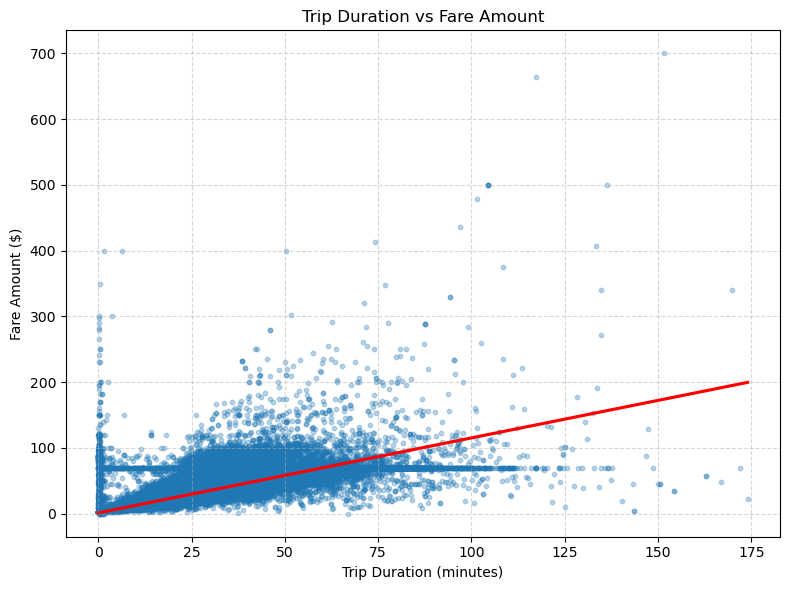

In [97]:
# Show relationship between fare and trip duration
df_nonzero['tpep_pickup_datetime'] = pd.to_datetime(df_nonzero['tpep_pickup_datetime'], errors='coerce')
df_nonzero['tpep_dropoff_datetime'] = pd.to_datetime(df_nonzero['tpep_dropoff_datetime'], errors='coerce')

df_nonzero['trip_duration'] = (df_nonzero['tpep_dropoff_datetime'] - df_nonzero['tpep_pickup_datetime']).dt.total_seconds() / 60
df_duration_fare = df_nonzero[
    (df_nonzero['trip_duration'] > 0) &
    (df_nonzero['trip_duration'] <= 180) &
    (df_nonzero['fare_amount'] > 0)
]
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_duration_fare,
    x='trip_duration',
    y='fare_amount',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'red'},
    ci=None
)

plt.title('Trip Duration vs Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



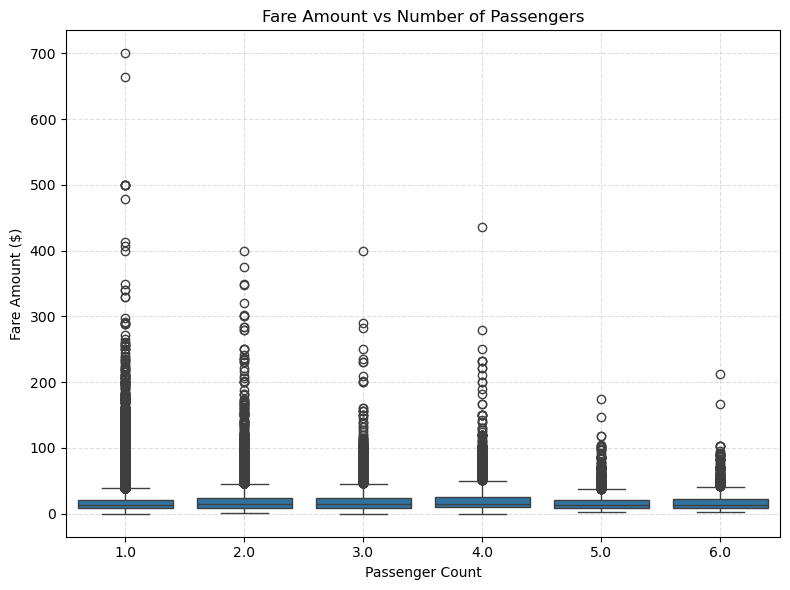

In [99]:
# Show relationship between fare and number of passengers
df_passenger_fare = df_nonzero[(df_nonzero['fare_amount'] > 0) & (df_nonzero['passenger_count'] > 0)]

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_passenger_fare,
    x='passenger_count',
    y='fare_amount'
)
plt.title('Fare Amount vs Number of Passengers')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



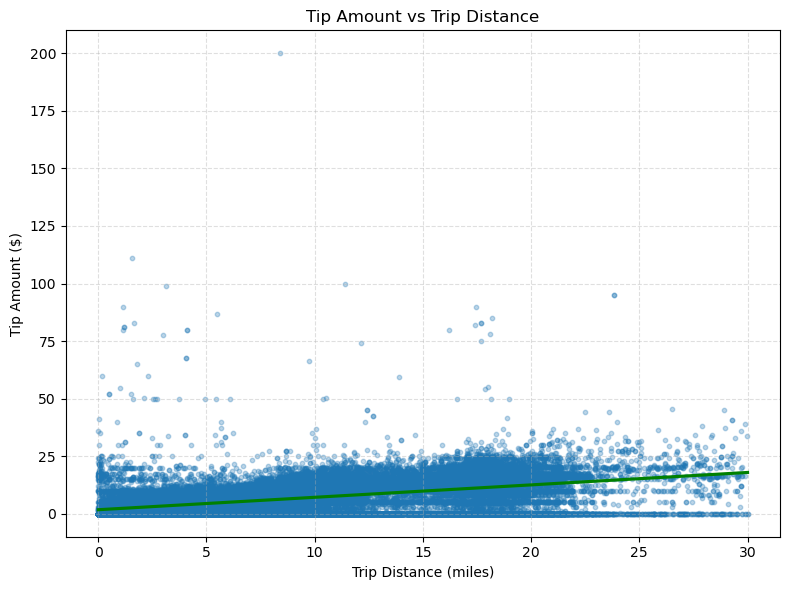

In [101]:
# Show relationship between tip and trip distance
df_tip_distance = df_nonzero[
    (df_nonzero['trip_distance'] > 0) &
    (df_nonzero['tip_amount'] >= 0)
]

df_tip_distance = df_tip_distance[df_tip_distance['trip_distance'] <= 30]
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_tip_distance,
    x='trip_distance',
    y='tip_amount',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'green'},
    ci=None
)
plt.title('Tip Amount vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

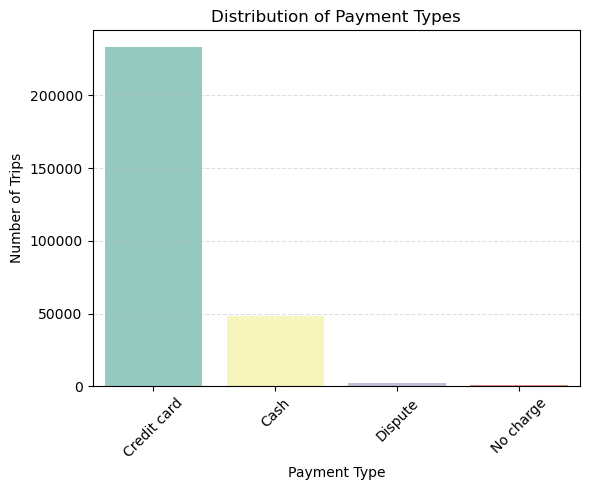

In [104]:
# Analyse the distribution of different payment types (payment_type).
payment_mapping = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}
df_nonzero['payment_type_label'] = df_nonzero['payment_type'].map(payment_mapping)
plt.figure(figsize=(6, 5))
sns.countplot(
    data=df_nonzero,
    x='payment_type_label',
    order=df_nonzero['payment_type_label'].value_counts().index,
    palette='Set3'
)

plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
!pip install geopandas


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [107]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file(r"C:\Users\bhav3\OneDrive\Desktop\Datasets and Dictionary\taxi_zones\taxi_zones.shp")
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

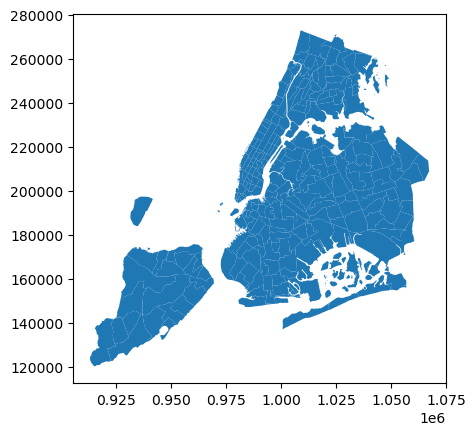

In [109]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [125]:
print(zones.columns)


Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')


In [129]:
# Merge zones and trip records using locationID and PULocationID
df_merged = df_nonzero.merge(
    zones[['LocationID', 'borough', 'zone', 'geometry']],
    how='left',
    left_on='PULocationID',
    right_on='LocationID'
)

df_merged.rename(columns={
    'borough': 'pickup_borough',
    'zone': 'pickup_zone',
    'geometry': 'pickup_geometry'
}, inplace=True)

df_merged.drop(columns=['LocationID'], inplace=True)



**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [131]:
# Group data by location and calculate the number of trips
pickup_counts = df_merged.groupby('pickup_zone').size().reset_index(name='num_trips') #group by
pickup_counts = pickup_counts.sort_values(by='num_trips', ascending=False)


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [137]:
# Merge trip counts back to the zones GeoDataFrame
zones = zones.merge(
    pickup_counts,
    how='left',
    left_on='zone',
    right_on='pickup_zone'
)
zones['num_trips'] = zones['num_trips'].fillna(0)


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

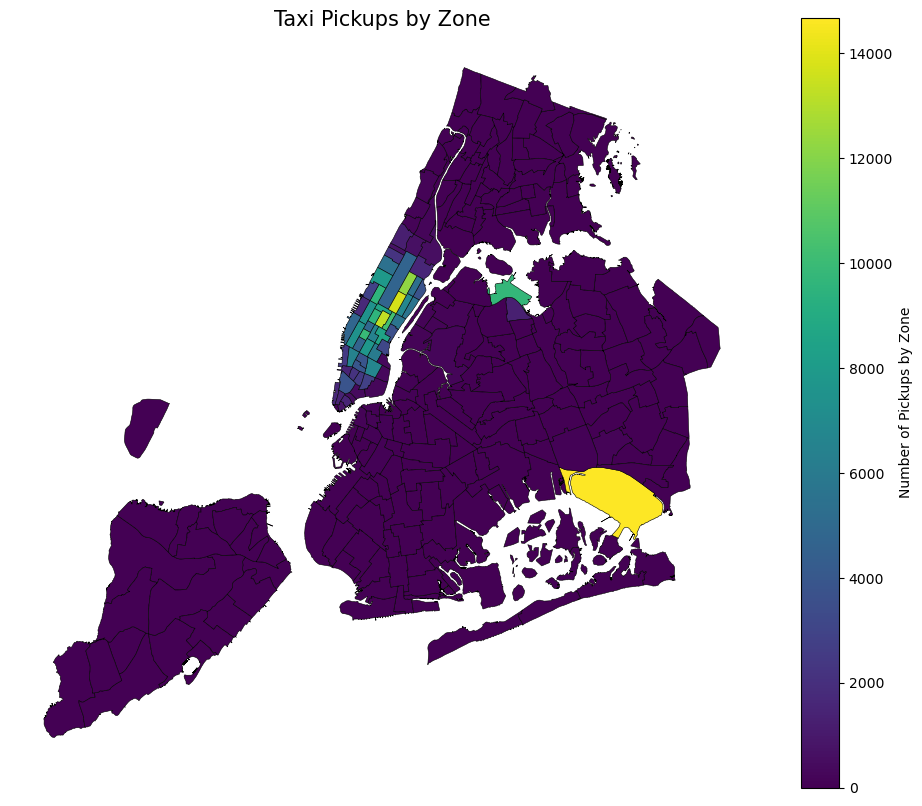

In [141]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones.plot(
    column='num_trips',             
    ax=ax,                                              
    legend=True,                    
    legend_kwds={
        'label': "Number of Pickups by Zone",
        'orientation': "vertical"
    },
    edgecolor='black',              
    linewidth=0.4
)

ax.set_title("Taxi Pickups by Zone", fontsize=15)
ax.axis("off")
plt.show()

In [147]:
# can you try displaying the zones DF sorted by the number of trips?
sorted_zones = zones.sort_values(by='num_trips', ascending=False)
sorted_zones[['zone', 'borough', 'num_trips']].head(10)


,zone,borough,num_trips
131,JFK Airport,Queens,14686.0
236,Upper East Side South,Manhattan,13764.0
160,Midtown Center,Manhattan,13279.0
235,Upper East Side North,Manhattan,12244.0
161,Midtown East,Manhattan,10276.0
185,Penn Station/Madison Sq West,Manhattan,9890.0
137,LaGuardia Airport,Queens,9696.0
141,Lincoln Square East,Manhattan,9544.0
229,Times Sq/Theatre District,Manhattan,9528.0
162,Midtown North,Manhattan,8535.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [153]:
# Find routes which have the slowest speeds at different times of the day
df_nonzero['trip_duration'] = (
    df_nonzero['tpep_dropoff_datetime'] - df_nonzero['tpep_pickup_datetime']
).dt.total_seconds() / 60  

df_nonzero = df_nonzero[df_nonzero['trip_duration'] > 0]

df_nonzero['route'] = df_nonzero['PULocationID'].astype(str) + ' → ' + df_nonzero['DOLocationID'].astype(str)

grouped = df_nonzero.groupby(['route', 'hour']).agg({
    'trip_distance': 'mean',
    'trip_duration': 'mean'
}).reset_index()

grouped['speed_mph'] = (grouped['trip_distance'] / grouped['trip_duration']) * 60



How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Busiest hour: 18:00 with 20438 trips


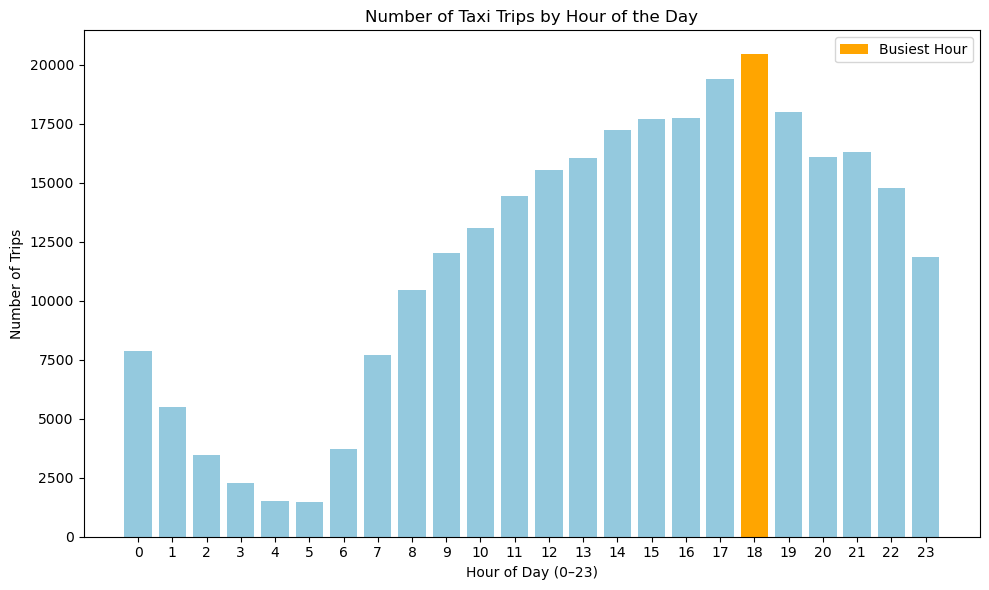

In [155]:
# Visualise the number of trips per hour and find the busiest hour
df_nonzero['pickup_hour'] = df_nonzero['tpep_pickup_datetime'].dt.hour
hourly_trip_counts = df_nonzero['pickup_hour'].value_counts().sort_index()
busiest_hour = hourly_trip_counts.idxmax()
num_trips_busiest = hourly_trip_counts.max()
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_trip_counts.index, y=hourly_trip_counts.values, color='skyblue')
plt.title("Number of Taxi Trips by Hour of the Day")
plt.xlabel("Hour of Day ")
plt.ylabel("Number of Trips")

# Highlight the busiest hour
plt.bar(busiest_hour, num_trips_busiest, color='orange', label='Busiest Hour')
plt.legend()
plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =



**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

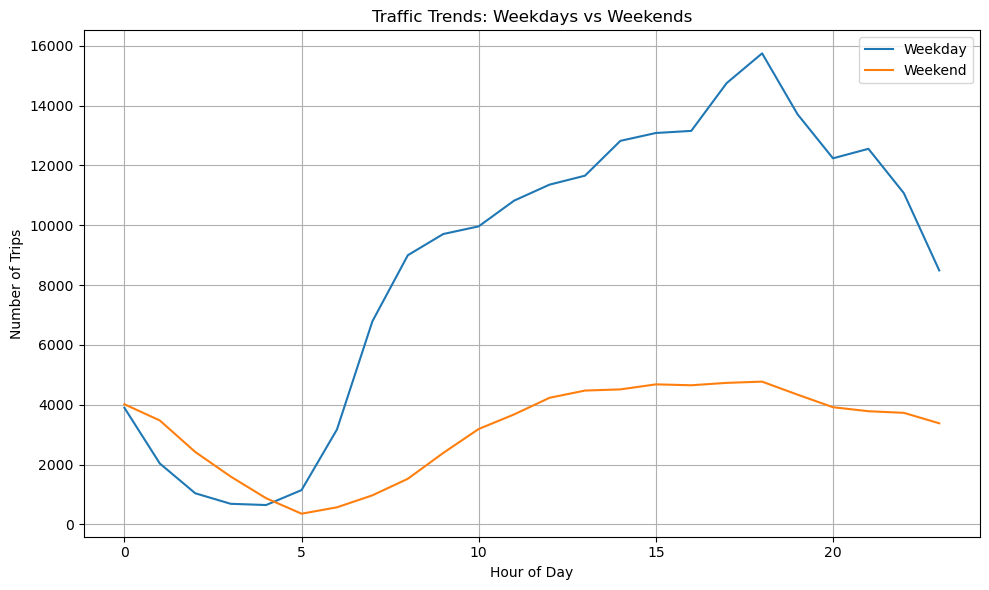

In [157]:
# Compare traffic trends for the week days and weekends
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
df['day_type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Group by day_type and hour to get traffic trend by time of day
df['hour'] = df['tpep_pickup_datetime'].dt.hour
traffic_by_type = df.groupby(['day_type', 'hour']).size().reset_index(name='num_trips') #group by

plt.figure(figsize=(10, 6))
for day_type in ['Weekday', 'Weekend']:
    subset = traffic_by_type[traffic_by_type['day_type'] == day_type]
    plt.plot(subset['hour'], subset['num_trips'], label=day_type)

plt.title('Traffic Trends: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

On weekdays, there are clear peaks in taxi demand during the morning and evening. This makes sense because these are the typical office commute hours.
On the other hand, weekends show a different pattern demand usually picks up later in the day, around noon or even late at night, which probably reflects people going out.
Early morning are generally the least busy,except maybe on Saturday and Sunday.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

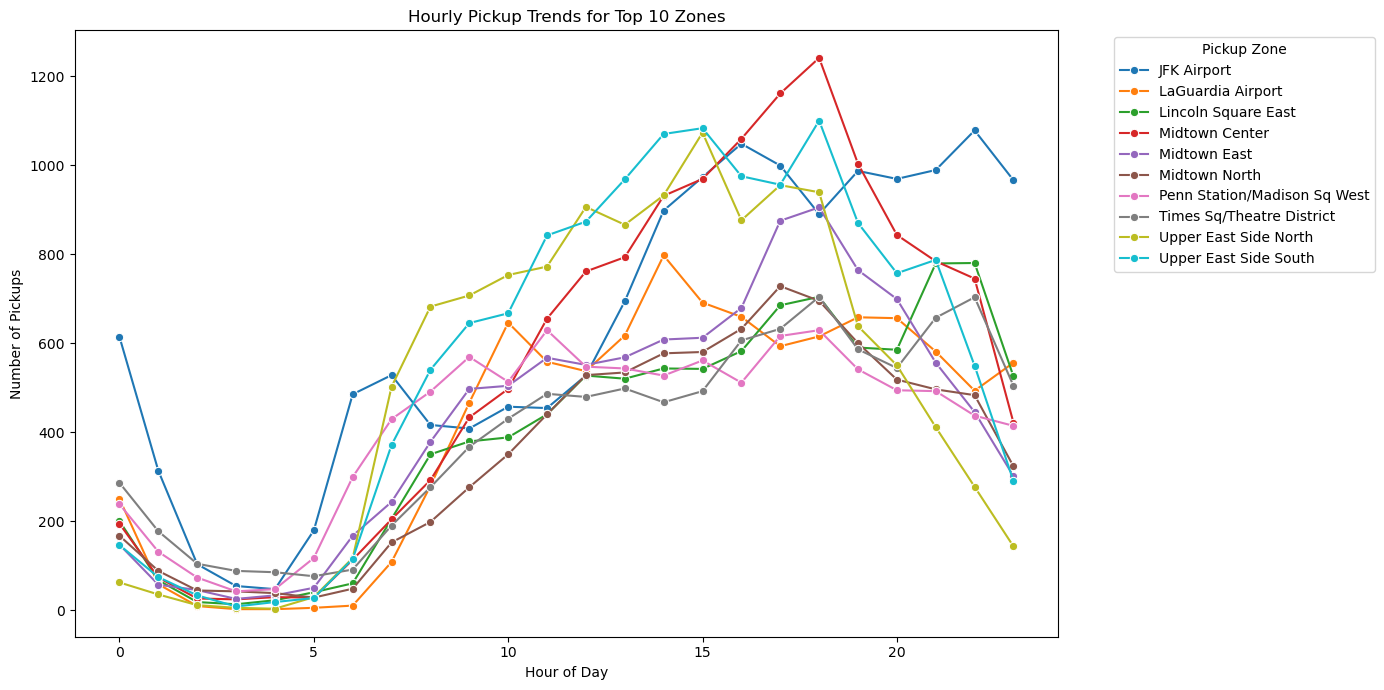

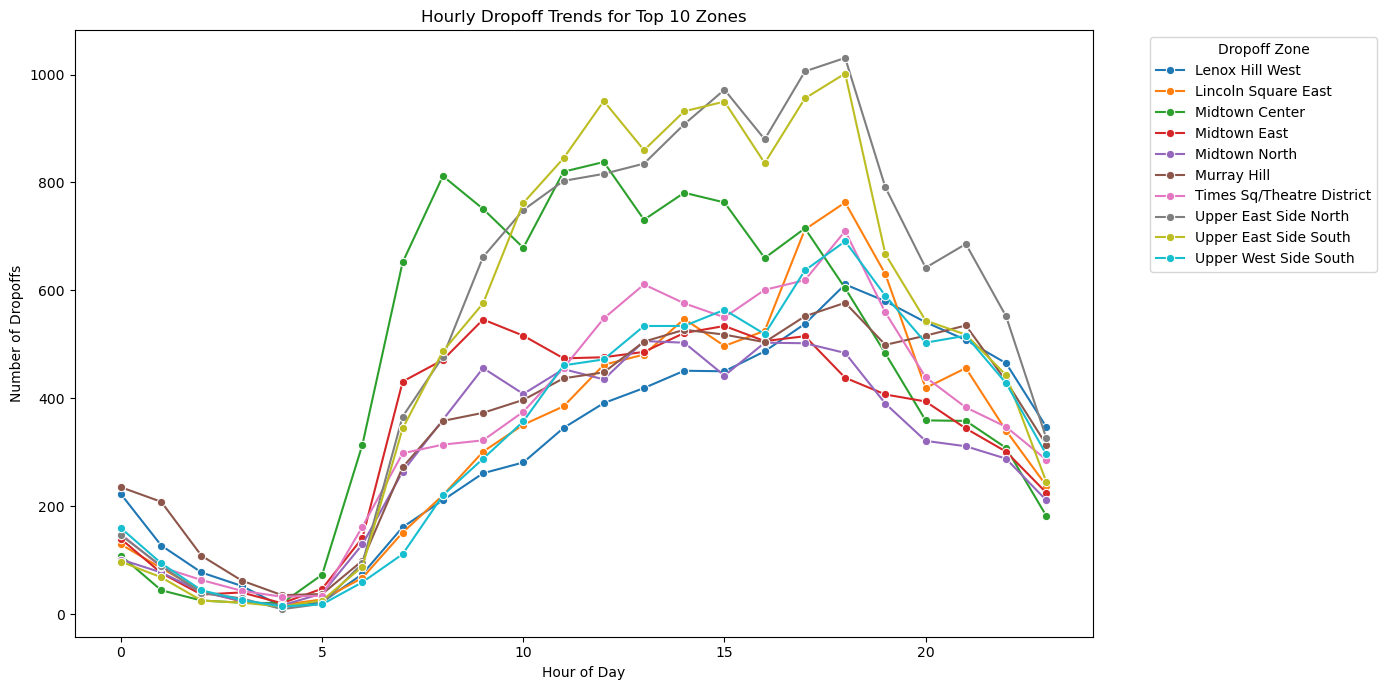

In [207]:
# Find top 10 pickup and dropoff zones
pickup_hourly = df_merged.groupby(['pickup_zone', 'hour']).size().reset_index(name='pickup_count') #group by
avg_pickups = pickup_hourly.groupby('pickup_zone')['pickup_count'].mean().sort_values(ascending=False).head(10)
top_pickup_zones = avg_pickups.index.tolist()
pickup_hourly_top = pickup_hourly[pickup_hourly['pickup_zone'].isin(top_pickup_zones)]
plt.figure(figsize=(14, 7))
sns.lineplot(data=pickup_hourly_top, x='hour', y='pickup_count', hue='pickup_zone', marker='o')
plt.title("Hourly Pickup Trends for Top 10 Zones")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.legend(title='Pickup Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
#drop off 
df_merged = df_merged.merge(
    zones[['LocationID', 'borough', 'zone']],
    how='left',
    left_on='DOLocationID',
    right_on='LocationID'
)
df_merged.rename(columns={
    'borough': 'dropoff_borough',
    'zone': 'dropoff_zone'
}, inplace=True)
df_merged.drop(columns=['LocationID'], inplace=True)

df_merged[['dropoff_zone']].head()
df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]
dropoff_hourly = df_merged.groupby(['dropoff_zone', 'hour']).size().reset_index(name='dropoff_count') #group by

dropoff_hourly = df_merged.groupby(['dropoff_zone', 'hour']).size().reset_index(name='dropoff_count') 
avg_dropoffs = dropoff_hourly.groupby('dropoff_zone')['dropoff_count'].mean().sort_values(ascending=False).head(10) 
top_dropoff_zones = avg_dropoffs.index.tolist()
dropoff_hourly_top = dropoff_hourly[dropoff_hourly['dropoff_zone'].isin(top_dropoff_zones)]
plt.figure(figsize=(14, 7))
sns.lineplot(data=dropoff_hourly_top, x='hour', y='dropoff_count', hue='dropoff_zone', marker='o')
plt.title("Hourly Dropoff Trends for Top 10 Zones")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Dropoffs")
plt.legend(title='Dropoff Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [221]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Total pickups
pickup_counts = df_merged['pickup_zone'].value_counts().reset_index()
pickup_counts.columns = ['zone', 'pickup_count']
dropoff_counts = df_merged['dropoff_zone'].value_counts().reset_index()
dropoff_counts.columns = ['zone', 'dropoff_count']
# merge
zone_ratios = pickup_counts.merge(dropoff_counts, on='zone', how='inner')
zone_ratios['pickup_dropoff_ratio'] = zone_ratios['pickup_count'] / zone_ratios['dropoff_count']
top10_ratio = zone_ratios.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
print("Top 10 zones by pickup/dropoff ratio:")
print(top10_ratio[['zone', 'pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']])

bottom10_ratio = zone_ratios.sort_values(by='pickup_dropoff_ratio').head(10)
print("\nBottom 10 zones by pickup/dropoff ratio:")
print(bottom10_ratio[['zone', 'pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']])

Top 10 zones by pickup/dropoff ratio:
                            zone  pickup_count  dropoff_count  \
46                 East Elmhurst          1330            141   
0                    JFK Airport         15492           3365   
5              LaGuardia Airport         10006           3498   
70                  North Corona            97             52   
6   Penn Station/Madison Sq West          9890           6116   
28       Greenwich Village South          3973           2807   
17                  West Village          6534           4749   
26                  Central Park          4673           3472   
4                   Midtown East         10276           8084   
25              Garment District          4848           3915   

    pickup_dropoff_ratio  
46              9.432624  
0               4.603863  
5               2.860492  
70              1.865385  
6               1.617070  
28              1.415390  
17              1.375869  
26              1.345910  
4  

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [223]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_hours = [23, 0, 1, 2, 3, 4, 5]
df_night = df_merged[df_merged['hour'].isin(night_hours)]
top_night_pickups = (
    df_night['pickup_zone']
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={'index': 'zone', 'pickup_zone': 'pickup_count'})
)

top_night_dropoffs = (
    df_night['dropoff_zone']
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={'index': 'zone', 'dropoff_zone': 'dropoff_count'})
)
print("Top 10 Pickup Zones (Night Hours 11PM-5AM):")
print(top_night_pickups)

print("\nTop 10 Dropoff Zones (Night Hours 11PM-5AM):")
print(top_night_dropoffs)



Top 10 Pickup Zones (Night Hours 11PM-5AM):
                   pickup_count  count
0                  East Village   2459
1                   JFK Airport   2340
2                  West Village   1975
3                  Clinton East   1619
4               Lower East Side   1534
5       Greenwich Village South   1462
6     Times Sq/Theatre District   1320
7  Penn Station/Madison Sq West   1062
8                 Midtown South    969
9                  East Chelsea    927

Top 10 Dropoff Zones (Night Hours 11PM-5AM):
                   dropoff_count  count
0                   East Village   1336
1                   Clinton East   1067
2                    Murray Hill    999
3                   East Chelsea    896
4                       Gramercy    890
5                Lenox Hill West    861
6                 Yorkville West    852
7                   West Village    769
8  Sutton Place/Turtle Bay North    756
9      Times Sq/Theatre District    693


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [233]:
# Filter for night hours (11 PM to 5 AM)
if 'hour' not in df_merged.columns:
    df_merged['hour'] = df_merged['tpep_pickup_datetime'].dt.hour
    
night_df = df_merged[(df_merged['hour'] >= 23) | (df_merged['hour'] <= 5)]
#Revenue
total_revenue = df_merged['total_amount'].sum()
night_revenue = night_df['total_amount'].sum()

# Calculate night revenue share
night_share = (night_revenue / total_revenue) * 100

print(f"Night Time Revenue Share (11PM–5AM): {night_share:.2f}%")



Night Time Revenue Share (11PM–5AM): 12.18%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

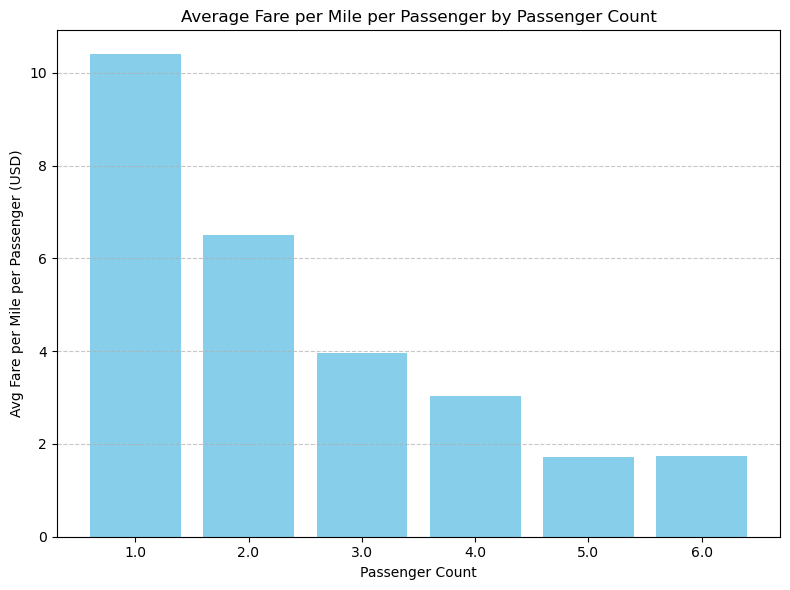

In [251]:
# Analyse the fare per mile per passenger for different passenger counts
valid_trips = df_merged[
    (df_merged['trip_distance'] > 0) &
    (df_merged['passenger_count'] > 0) &
    (df_merged['fare_amount'] > 0)
]

# Calculate fare per mile per passenger
valid_trips['fare_per_mile_per_passenger'] = (
    valid_trips['fare_amount'] / valid_trips['trip_distance']
) / valid_trips['passenger_count']

# Group by passenger count and calculate average
avg_fare_per_mile_per_passenger = valid_trips.groupby('passenger_count')[ #group by
    'fare_per_mile_per_passenger'
].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.bar(avg_fare_per_mile_per_passenger['passenger_count'].astype(str),
        avg_fare_per_mile_per_passenger['fare_per_mile_per_passenger'],
        color='skyblue')
plt.xlabel('Passenger Count')
plt.ylabel('Avg Fare per Mile per Passenger (USD)')
plt.title('Average Fare per Mile per Passenger by Passenger Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


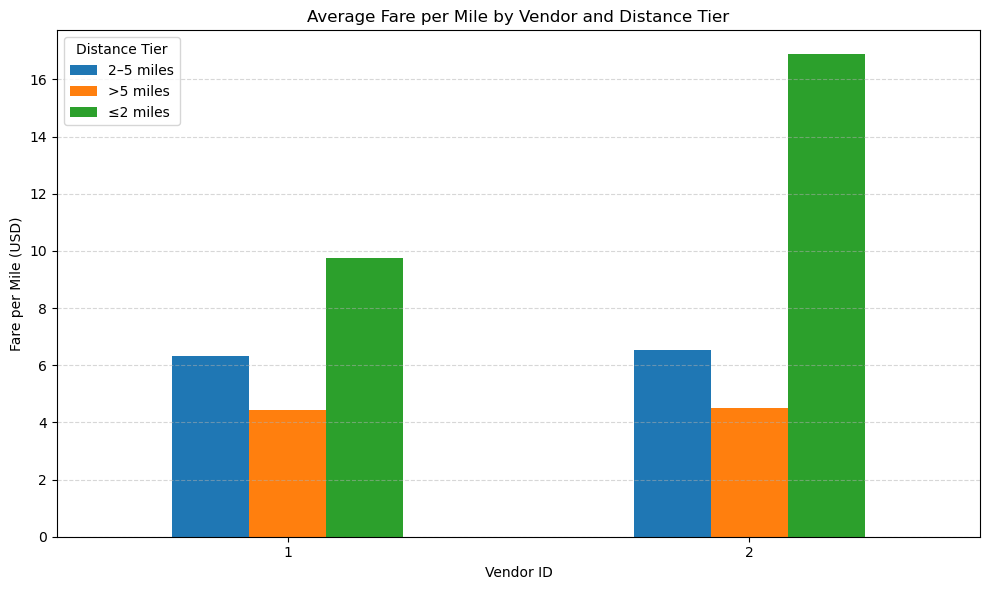

In [237]:
# Defining distance tiers
tiered_df = df_merged[(df_merged['fare_amount'] > 0) & (df_merged['trip_distance'] > 0)].copy()
#per mile
tiered_df['fare_per_mile'] = tiered_df['fare_amount'] / tiered_df['trip_distance']
#tiers
def get_distance_tier(dist):
    if dist <= 2:
        return '≤2 miles'
    elif dist <= 5:
        return '2–5 miles'
    else:
        return '>5 miles'

tiered_df['distance_tier'] = tiered_df['trip_distance'].apply(get_distance_tier)
# Group by Vendor and Tier
vendor_fare_comparison = tiered_df.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().reset_index()
pivot_fare = vendor_fare_comparison.pivot(index='VendorID', columns='distance_tier', values='fare_per_mile')
pivot_fare.plot(kind='bar', figsize=(10, 6))
plt.title('Average Fare per Mile by Vendor and Distance Tier')
plt.ylabel('Fare per Mile (USD)')
plt.xlabel('Vendor ID')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.legend(title='Distance Tier')
plt.tight_layout()
plt.show()


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

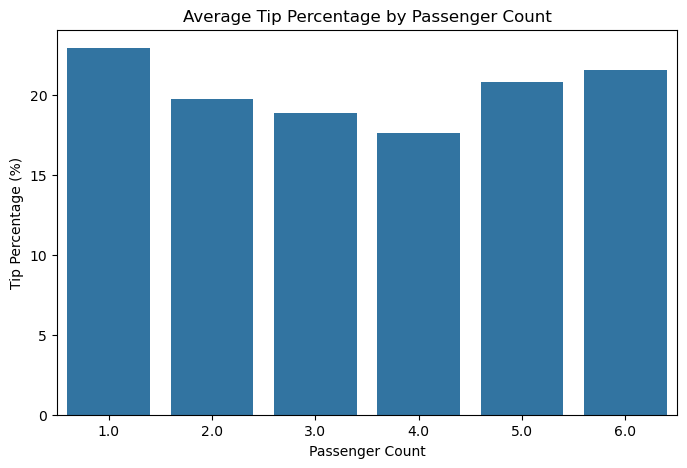

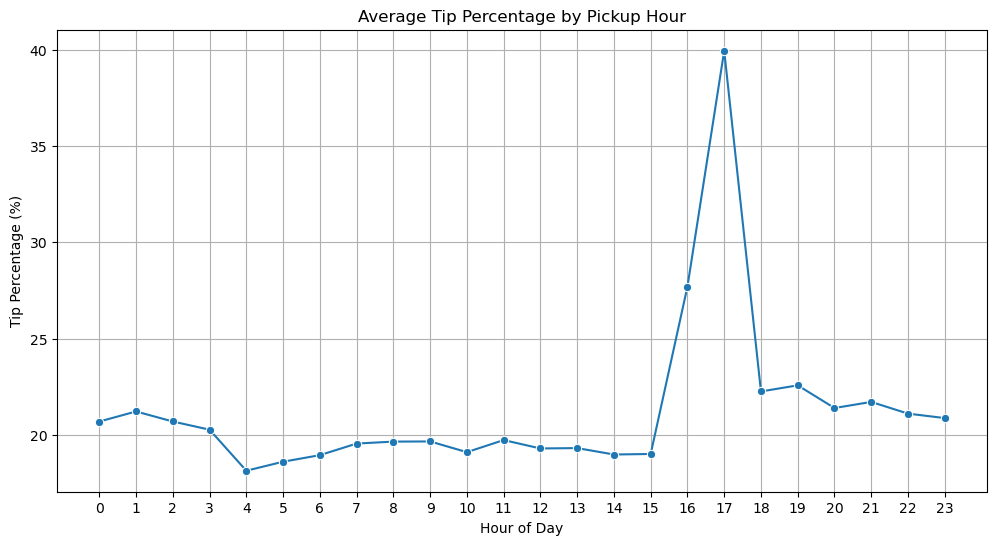

In [243]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_merged = df_merged[df_merged['fare_amount'] > 0]
df_merged['tip_percentage'] = (df_merged['tip_amount'] / df_merged['fare_amount']) * 100
#passenger counts
passenger_tip = df_merged.groupby('passenger_count')['tip_percentage'].mean().reset_index() #group by
plt.figure(figsize=(8, 5))
sns.barplot(data=passenger_tip, x='passenger_count', y='tip_percentage')
plt.title('Average Tip Percentage by Passenger Count')
plt.ylabel('Tip Percentage (%)')
plt.xlabel('Passenger Count')
plt.show()
#4 pickup time
pickup_tip = df_merged.groupby('hour')['tip_percentage'].mean().reset_index() #group by
plt.figure(figsize=(12, 6))
sns.lineplot(data=pickup_tip, x='hour', y='tip_percentage', marker='o')
plt.title('Average Tip Percentage by Pickup Hour')
plt.ylabel('Tip Percentage (%)')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()




Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

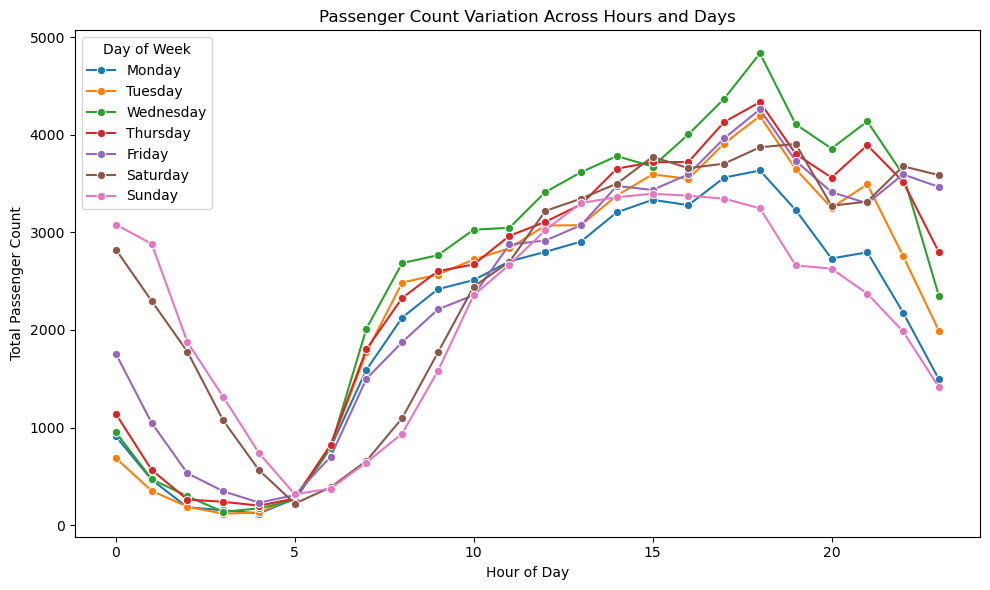

In [249]:
# See how passenger count varies across hours and days
df_merged['hour'] = df_merged['tpep_pickup_datetime'].dt.hour
df_merged['day_name'] = df_merged['tpep_pickup_datetime'].dt.day_name()

passenger_hourly = df_merged.groupby(['day_name', 'hour'])['passenger_count'].sum().reset_index()

# Order the days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
passenger_hourly['day_name'] = pd.Categorical(passenger_hourly['day_name'], categories=day_order, ordered=True)
passenger_hourly.sort_values(by=['day_name', 'hour'], inplace=True)
plt.figure(figsize=(10, 6))
sns.lineplot(data=passenger_hourly, x='hour', y='passenger_count', hue='day_name', marker='o')
plt.title('Passenger Count Variation Across Hours and Days')
plt.xlabel('Hour of Day')
plt.ylabel('Total Passenger Count')
plt.legend(title='Day of Week')
plt.tight_layout()
plt.show()



**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones



In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
# Based on the data analysis, here are some suggestions to improve taxi routing and dispatch:

# Plan for Rush Hours: 
#Most weekday trips happen in the morning (7–10 AM) and evening (5–8 PM). More cabs should be available in busy areas like Midtown during these times.

# Focus on Night Zones: 
#Zones like Greenwich Village and Lincoln Square are more active at night. Sending more cabs there between 11 PM to 5 AM can help increase revenue.

# Fix Slow Routes: Some routes are slower at certain hours. Avoid sending cabs through these areas when traffic is bad.

# Balance Pickups and Dropoffs: Some zones have high dropoffs but low pickups. Cabs should be re-routed to such places to reduce idle time.

# Use Passenger Trends: In areas with more group rides, larger taxis or shared rides can work better.

# These ideas can help make the taxi service more efficient and improve both driver earnings and customer experience.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
# Morning Rush (7–10 AM, Weekdays):
# Place more cabs in residential areas like Upper East Side and East Harlem since people are usually heading to work.

# Evening Rush (5–8 PM, Weekdays):
# Focus on business zones like Midtown where people are leaving offices and heading home.

# Late Night (11 PM–2 AM, Weekends):
# Cabs should be near nightlife areasl like Times Square

# Weekends (Afternoon):
# Keep more cabs around places like Central Park

# Low Pickup Zones:
# If a zone has many drop-offs but not many pickups, send some cabs there to avoid them being idle elsewhere.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
# Distance-Based pricing:

# Lower fare per mile for long trips (5+ miles) to stay competitive.

# Slightly higher per-mile rate for mid-range trips (2–5 miles).

# Fixed base fare + premium for very short trips (<2 miles).

# Increase prices a bit during weekend afternoons and late nights when demand peaks around leisure and nightlife spots.

# Offer discounts or promo fares during early mornings (2–5 AM) or in underutilized zones to attract more riders and balance demand.

# By adjusting prices based on time, distance, and demand zones, we can improve profitability while still offering fair and competitive rates.
